Maria Navarro  
Spring 2024  
Advanced Healthcare Analytics and Data Mining
Smart ICU Bed Allocation System - SIBAS  
Predictive Analytics for Risk Profiling and Triaging Covid-19 Patients  

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import make_scorer, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from sklearn.linear_model import LogisticRegression
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler

### **Data Processing**

In [2]:
raw_df = pd.read_csv('final_complete_data.csv')

C:\Users\mfncn\AppData\Local\Temp\ipykernel_9712\553678273.py:1: DtypeWarning: Columns (18,19,20,21,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv('final_complete_data.csv')


In [3]:
# Remove unnecessary columns
columns_to_remove = ['Patient ID', 'AgeCode', 'SexCode', 'DX0', 'DX1', 'DX2', 'DX3', 'DX4', 'DX5', 'DX6', 'DX7', 'DX8', 'DX9', 'DX10', 'DX11', 'DX12', 'DX13', 'DX14', 'DX15', 'DX16', 'DX17', 'DX18', 'DX19', 'DX20', 'AgeBins']
df = raw_df.drop(columns=columns_to_remove)

In [4]:
df

,Mortality,GenderMale,Age_18_39,Age_40_49,Age_50_59,Age_60_69,Age_70_74,Age_75_99,Undefined_Undefined,CHEST_Chest_Wall_A,...,UROLG_GEN_Status_A,EYE___Malignant,BEHAV_Other_Nos_A,NEURO_Head_B,UROLG_GEN_Status2,UROLG_GEN_Status_B,UROLG_GEN_Screening,EYE___Macular_Degeneration,MSKLT_Status_A,GENRL_UNSP_Trauma
0,0,0,False,False,False,False,True,False,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,False,False,False,True,False,False,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,False,False,False,True,False,False,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,False,False,True,False,False,False,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,False,False,False,False,True,False,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370628,0,0,False,False,False,False,False,True,0,0,...,0,0,0,0,0,0,0,0,0,0
370629,1,0,False,False,False,False,False,True,0,0,...,0,0,1,0,0,0,0,0,0,0
370630,0,1,True,False,False,False,False,False,0,0,...,0,0,0,0,0,0,0,0,0,0
370631,0,1,False,False,False,False,False,True,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
# Checking number of nulls
null_counts = df.isnull().sum()
print(null_counts)

Mortality                     0
GenderMale                    0
Age_18_39                     0
Age_40_49                     0
Age_50_59                     0
                             ..
UROLG_GEN_Status_B            0
UROLG_GEN_Screening           0
EYE___Macular_Degeneration    0
MSKLT_Status_A                0
GENRL_UNSP_Trauma             0
Length: 228, dtype: int64


In [6]:
df['Mortality'].value_counts()

Mortality
0    349363
1     21270
Name: count, dtype: int64

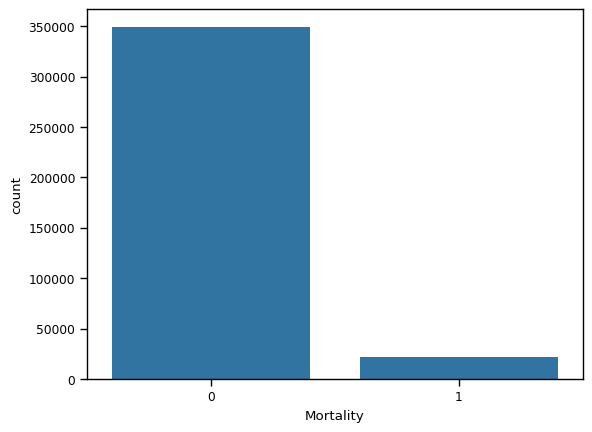

In [7]:
# Check class imbalance
sns.set_context('paper')
sns.countplot(data=df, x='Mortality')
plt.show()

# This is highly imbalanced

C:\Users\mfncn\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\mfncn\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


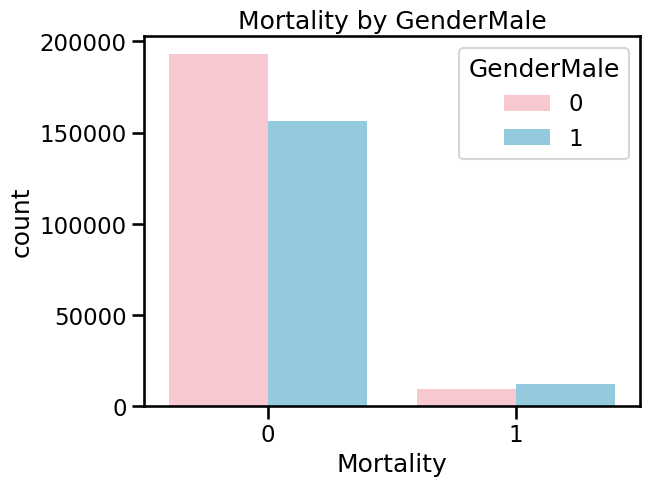

In [8]:
# Plot Mortality by Gender
sns.set_context('talk')
sns.countplot(data=df, x='Mortality', hue='GenderMale', palette=['pink', 'skyblue'])
plt.title('Mortality by GenderMale')
plt.show()

In [9]:
raw_df.AgeBins.unique()

array(['Age_70_74', 'Age_60_69', 'Age_50_59', 'Age_75_99', 'Age_40_49',
       'Age_18_39', 'RefUnder18'], dtype=object)

C:\Users\mfncn\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\mfncn\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


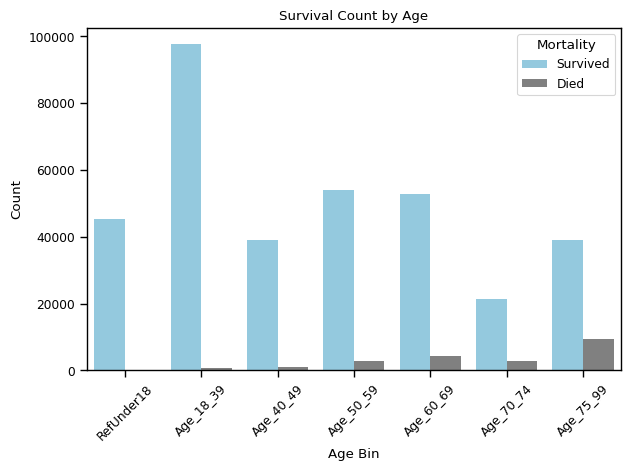

In [10]:
# Define the order of age bins
age_bin_order = ['RefUnder18','Age_18_39', 'Age_40_49', 'Age_50_59', 'Age_60_69', 'Age_70_74', 'Age_75_99']

# Plot the relationship between age bins and mortality
sns.set_context('paper')
sns.countplot(data=raw_df, x='AgeBins', hue='Mortality', palette=['skyblue', 'gray'], order=age_bin_order)
plt.xlabel('Age Bin')
plt.ylabel('Count')
plt.title('Survival Count by Age')
plt.legend(title='Mortality', labels=['Survived', 'Died'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

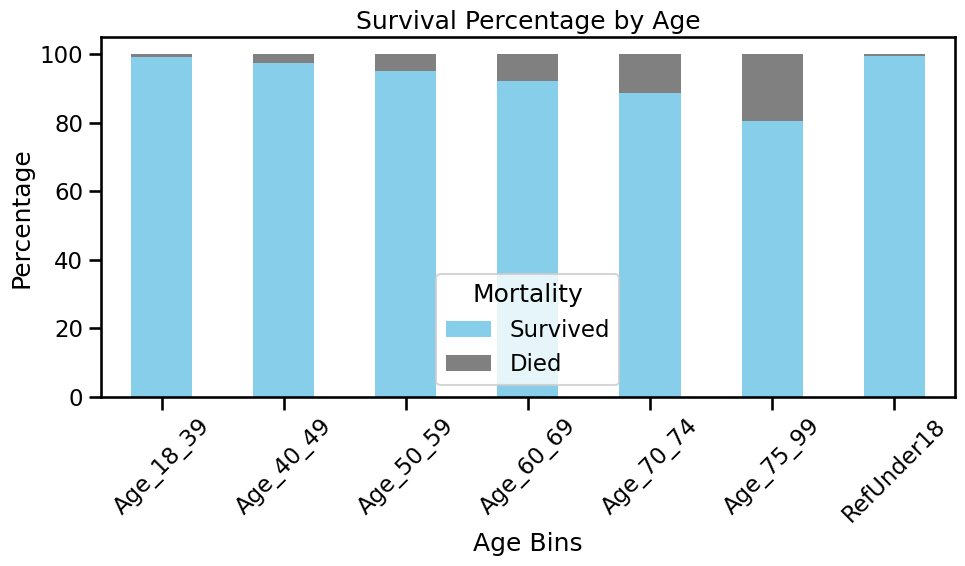

In [11]:
# Plotting Mortality Percentage by Age
# Calculate the counts of each combination of age bin and mortality
counts = raw_df.groupby(['AgeBins', 'Mortality']).size().unstack(fill_value=0)

# Normalize the counts to percentages
counts_percent = counts.div(counts.sum(axis=1), axis=0) * 100

# Plot the stacked bar plot
sns.set_context('talk')
counts_percent.plot(kind='bar', stacked=True, color=['skyblue', 'gray'], figsize=(10, 6))

plt.xlabel('Age Bins')
plt.ylabel('Percentage')
plt.title('Survival Percentage by Age')
plt.xticks(rotation=45)
plt.legend(title='Mortality', labels=['Survived', 'Died'])
plt.tight_layout()
plt.show()

In [9]:
#Separate X from y
X = df.drop(columns=['Mortality'])  # Features
y = df['Mortality']  # Target variable

# Split the data into train and test sets (75% train, 25% test)
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Print the shapes of the train and test sets
#print("X_train shape:", X_train.shape)
#print("y_train shape:", y_train.shape)
#print("X_test shape:", X_test.shape)
#print("y_test shape:", y_test.shape)

In [13]:
# Split the data into train and test sets, and perform undersampling on the training set
def train_test_undersample(X, y, test_size=0.25, target_label=1):
    
    # Reset index of DataFrame
    if isinstance(X, pd.DataFrame):
        X = X.reset_index(drop=True)
    if isinstance(y, pd.Series):
        y = y.reset_index(drop=True)

    # Split the data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=42)

    # Undersample the majority class using RandomUnderSampler
    rus = RandomUnderSampler(sampling_strategy='auto', random_state=42)
    X_train_balanced, y_train_balanced = rus.fit_resample(X_train, y_train)

    return X_train_balanced, X_test, y_train_balanced, y_test

X_train, X_test, y_train, y_test = train_test_undersample(X, y, test_size=0.25, target_label=1)

# Check the class distribution after undersampling
print("Class distribution in the training set after undersampling:", Counter(y_train))
print("Class distribution in the testing set:", Counter(y_test))


Class distribution in the training set after undersampling: Counter({0: 15952, 1: 15952})
Class distribution in the testing set: Counter({0: 87341, 1: 5318})


### **PCA**

In [14]:
# Scale features before applying PCA to ensure that each feature contributes equally to variance
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA
n_components = 200
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

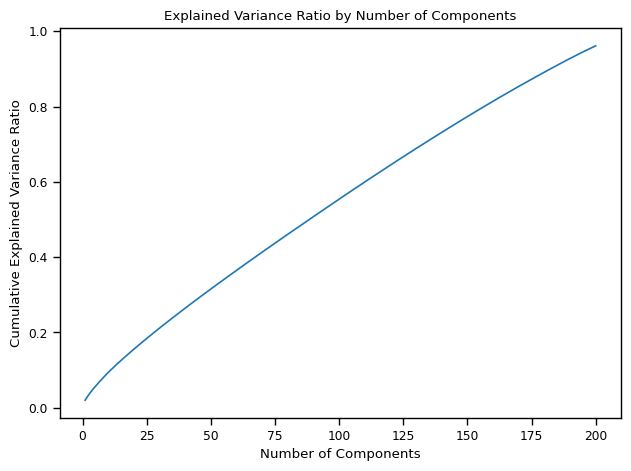

In [19]:
# Evaluate explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Plot cumulative explained variance ratio
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)
sns.set_context('paper')
plt.plot(range(1, n_components + 1), cumulative_variance_ratio)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Explained Variance Ratio by Number of Components')
plt.tight_layout()
plt.show()

The plot of explained variance ratio by the number of components appears to be linear. This suggests that each additional principal component contributes roughly the same amount of variance to the total variance explained. Here's what it could mean:
- Linear Increase in Explained Variance: Each principal component captures a similar amount of variance in the data, resulting in a linear increase in the cumulative explained variance ratio as the number of components increases. This suggests that each additional component adds valuable information to the representation of the data.
- No Clear Dominant Components: In some cases, there may not be dominant components that explain a significantly larger proportion of variance compared to others. Instead, the variance is distributed relatively evenly across multiple components, leading to a linear trend in the explained variance ratio plot.

### **Modeling**

Training Logistic Regression

In [60]:
# Define model
lr = LogisticRegression(max_iter=1000)

# Define parameter grid
param_grid = {
    'penalty': [None, 'l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'sag', 'saga']
}

# Conduct grid search with cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search_lr = GridSearchCV(estimator=lr, param_grid=param_grid, cv=cv, scoring='f1', verbose=1, n_jobs=-1)
grid_search_lr.fit(X_train_scaled, y_train)

# Evaluate the best model
best_model_lr = grid_search_lr.best_estimator_
#y_pred = best_model.predict(X_test_scaled)

print("Best Parameters:", grid_search_lr.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'saga'}


In [27]:
def evaluate_model_cv(model, X, y, cv):
    # Define scoring metrics
    scoring = {
        'precision': make_scorer(precision_score),
        'recall': make_scorer(recall_score),
        'f1': make_scorer(f1_score),
        'roc_auc': make_scorer(roc_auc_score),
        'pr_auc': make_scorer(average_precision_score)
    }
    
    # Perform cross-validation and calculate precision, recall, and F1-score
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    
    # Get the mean scores
    precision_mean = scores['test_precision'].mean()
    recall_mean = scores['test_recall'].mean()
    f1_mean = scores['test_f1'].mean()
    roc_auc_mean = scores['test_roc_auc'].mean()
    pr_auc_mean = scores['test_pr_auc'].mean()
    
    return precision_mean, recall_mean, f1_mean, roc_auc_mean, pr_auc_mean

In [29]:
def evaluate_on_test(model, X_test, y_test):
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    # Calculate precision, recall, and F1-score
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)  # AUC-ROC
    pr_auc = average_precision_score(y_test, y_pred)  # AUC-PR
    
    return precision, recall, f1, roc_auc, pr_auc


In [61]:
# Evaluating performance
print("Logistic Regression Metrics:")
precision_lr, recall_lr, f1_lr, roc_auc_mean_lr, pr_auc_mean_lr = evaluate_model_cv(best_model_lr, X_train_scaled, y_train, cv)
# Print the results
print("Train Set:")
print("Precision (Mean):", precision_lr)
print("Recall (Mean):", recall_lr)
print("F1-score (Mean):", f1_lr)
print("AUC-ROC (Mean):", roc_auc_mean_lr)
print("AUC-PR (Mean):", pr_auc_mean_lr)

print()

precision_lr_test, recall_lr_test, f1_lr_test, roc_auc_lr_test, pr_auc_lr_test = evaluate_on_test(best_model_lr, X_test_scaled, y_test)
# Print precision, recall, and F1-score
print("Test Set:")
print("Precision:", precision_lr_test)
print("Recall:", recall_lr_test)
print("F1-score:", f1_lr_test)
print("AUC-ROC:", roc_auc_lr_test)
print("AUC-PR:", pr_auc_lr_test)

Logistic Regression Metrics:
Train Set:
Precision (Mean): 0.9425437111640358
Recall (Mean): 0.9366850143772307
F1-score (Mean): 0.9395982140831615
AUC-ROC (Mean): 0.9397882858234711
AUC-PR (Mean): 0.9145219349199015

Test Set:
Precision: 0.5010046212577858
Recall: 0.9377585558480632
F1-score: 0.6530906233630173
AUC-ROC: 0.9404447511840126
AUC-PR: 0.47339360809482


In [31]:
from sklearn.metrics import confusion_matrix

def calculate_confusion_matrix(model, X, y, cv):
    # Initialize an empty list to store confusion matrices for each fold
    conf_matrices = []

    # Perform cross-validation with Stratified K-Fold and calculate confusion matrix for each fold
    for train_index, test_index in cv.split(X, y):
        X_train_fold, X_test_fold = X[train_index], X[test_index]
        y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]
        
        model.fit(X_train_fold, y_train_fold)
        y_pred_fold = model.predict(X_test_fold)
        
        # Calculate confusion matrix for the current fold
        conf_matrices.append(confusion_matrix(y_test_fold, y_pred_fold))

    # Aggregate confusion matrices across all folds
    conf_matrix_sum = sum(conf_matrices)
    
    return conf_matrix_sum

In [62]:
conf_matrix_lr = calculate_confusion_matrix(best_model_lr, X_train_scaled, y_train, cv)
print("Aggregated Confusion Matrix:")
print(conf_matrix_lr)

Aggregated Confusion Matrix:
[[15041   911]
 [ 1010 14942]]


In [64]:
# Training logistic regression with l1 regularization

# Define model
lr = LogisticRegression()

# Define parameter grid
param_grid = {
    'penalty': ['l1'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear']
}

# Conduct grid search with cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search_lr1 = GridSearchCV(estimator=lr, param_grid=param_grid, cv=cv, scoring='f1', verbose=1, n_jobs=-1)
grid_search_lr1.fit(X_train_scaled, y_train)

# Evaluate the best model
best_model_lr1 = grid_search_lr1.best_estimator_
#y_pred = best_model.predict(X_test_scaled)

print("Best Parameters:", grid_search_lr1.best_params_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}


In [65]:
# Evaluating performance
print("Logistic Regression l1 Metrics:")
precision_lr1, recall_lr1, f1_lr1, roc_auc_mean_lr1, pr_auc_mean_lr1 = evaluate_model_cv(best_model_lr1, X_train_scaled, y_train, cv)
# Print the results
print("Train Set:")
print("Precision (Mean):", precision_lr1)
print("Recall (Mean):", recall_lr1)
print("F1-score (Mean):", f1_lr1)
print("AUC-ROC (Mean):", roc_auc_mean_lr1)
print("AUC-PR (Mean):", pr_auc_mean_lr1)

print()

precision_lr1_test, recall_lr1_test, f1_lr1_test, roc_auc_lr1_test, pr_auc_lr1_test = evaluate_on_test(best_model_lr1, X_test_scaled, y_test)
# Print precision, recall, and F1-score
print("Test Set:")
print("Precision:", precision_lr1_test)
print("Recall:", recall_lr1_test)
print("F1-score:", f1_lr1_test)
print("AUC-ROC:", roc_auc_lr1_test)
print("AUC-PR:", pr_auc_lr1_test)

Logistic Regression l1 Metrics:
Train Set:
Precision (Mean): 0.9428124514868976
Recall (Mean): 0.9361208885884968
F1-score (Mean): 0.9394468558040261
AUC-ROC (Mean): 0.9396629529171484
AUC-PR (Mean): 0.9145209755480757

Test Set:
Precision: 0.5042449969678593
Recall: 0.9381346370816096
F1-score: 0.6559295293189588
AUC-ROC: 0.9409877224748106
AUC-PR: 0.4766003507019904


Training a Random Forest

In [33]:
from sklearn.ensemble import RandomForestClassifier

In [34]:
# Define model
rf = RandomForestClassifier()

# Define parameter grid
param_grid = {
    'n_estimators': [100]#, 200, 300],
    #'max_depth': [None, 10, 20],
    #'min_samples_split': [2, 5, 10],
    #'min_samples_leaf': [1, 2, 4]
}

# Perform grid search with cross-validation
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid, cv=cv, scoring='f1', verbose=1, n_jobs=-1)
grid_search_rf.fit(X_train_scaled, y_train)

best_model_rf = grid_search_rf.best_estimator_
#y_pred_rf = best_model_rf.predict(X_test_scaled)

print("Best Parameters (Random Forest):", grid_search_rf.best_params_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best Parameters (Random Forest): {'n_estimators': 100}


In [37]:
precision_rf, recall_rf, f1_rf, roc_auc_mean_rf, pr_auc_mean_rf = evaluate_model_cv(best_model_rf, X_train_scaled, y_train, cv)
# Print the results
print("Train Set:")
print("Precision (Mean):", precision_rf)
print("Recall (Mean):", recall_rf)
print("F1-score (Mean):", f1_rf)
print("AUC-ROC (Mean):", roc_auc_mean_rf)
print("AUC-PR (Mean):", pr_auc_mean_rf)

print()

precision_rf_test, recall_rf_test, f1_rf_test, roc_auc_rf_test, pr_auc_rf_test = evaluate_on_test(best_model_rf, X_test_scaled, y_test)
# Print precision, recall, and F1-score
print("Test Set:")
print("Precision:", precision_rf_test)
print("Recall:", recall_rf_test)
print("F1-score:", f1_rf_test)
print("AUC-ROC:", roc_auc_rf_test)
print("AUC-PR:", pr_auc_rf_test)


Train Set:
Precision (Mean): 0.9360145050661071
Recall (Mean): 0.9175023012410491
F1-score (Mean): 0.9266479079972259
AUC-ROC (Mean): 0.9273760350672788
AUC-PR (Mean): 0.9000327707685296

Test Set:
Precision: 0.4813204190551492
Recall: 0.9157578036855961
F1-score: 0.6309924850997668
AUC-ROC: 0.9278357376930859
AUC-PR: 0.4456078622094666


In [36]:
conf_matrix_rf = calculate_confusion_matrix(best_model_rf, X_train_scaled, y_train, cv)
print("Aggregated Confusion Matrix:")
print(conf_matrix_rf)

Aggregated Confusion Matrix:
[[14956   996]
 [ 1302 14650]]


In [38]:
# Define model
rf = RandomForestClassifier()

# Define parameter grid
param_grid = {
    'n_estimators': [300]#, 200, 300],
    #'max_depth': [None, 10, 20],
    #'min_samples_split': [2, 5, 10],
    #'min_samples_leaf': [1, 2, 4]
}

# Perform grid search with cross-validation
grid_search_rf_300 = GridSearchCV(estimator=rf, param_grid=param_grid, cv=cv, scoring='f1', verbose=1, n_jobs=-1)
grid_search_rf_300.fit(X_train_scaled, y_train)

best_model_rf_300 = grid_search_rf_300.best_estimator_
#y_pred_rf = best_model_rf.predict(X_test_scaled)

print("Best Parameters (Random Forest):", grid_search_rf_300.best_params_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best Parameters (Random Forest): {'n_estimators': 300}


In [40]:
precision_rf_300, recall_rf_300, f1_rf_300, roc_auc_mean_rf_300, pr_auc_mean_rf_300 = evaluate_model_cv(best_model_rf_300, X_train_scaled, y_train, cv)
# Print the results
print("Train Set:")
print("Precision (Mean):", precision_rf_300)
print("Recall (Mean):", recall_rf_300)
print("F1-score (Mean):", f1_rf_300)
print("AUC-ROC (Mean):", roc_auc_mean_rf_300)
print("AUC-PR (Mean):", pr_auc_mean_rf_300)

print()

precision_rf_300_test, recall_rf_300_test, f1_rf_300_test, roc_auc_rf_300_test, pr_auc_rf_300_test = evaluate_on_test(best_model_rf_300, X_test_scaled, y_test)
# Print precision, recall, and F1-score
print("Test Set:")
print("Precision:", precision_rf_300_test)
print("Recall:", recall_rf_300_test)
print("F1-score:", f1_rf_300_test)
print("AUC-ROC:", roc_auc_rf_300_test)
print("AUC-PR:", pr_auc_rf_300_test)

Train Set:
Precision (Mean): 0.9370040683452656
Recall (Mean): 0.918693366629696
F1-score (Mean): 0.9277367814708312
AUC-ROC (Mean): 0.9284417380779996
AUC-PR (Mean): 0.9014620147828826

Test Set:
Precision: 0.4804760499655749
Recall: 0.9185784129371944
F1-score: 0.630933161123668
AUC-ROC: 0.9290514029170005
AUC-PR: 0.4460279759213332


In [41]:
conf_matrix_rf_300 = calculate_confusion_matrix(best_model_rf_300, X_train_scaled, y_train, cv)
print("Aggregated Confusion Matrix:")
print(conf_matrix_rf_300)

Aggregated Confusion Matrix:
[[14951  1001]
 [ 1282 14670]]


In [44]:
# Define model
rf = RandomForestClassifier()

# Define parameter grid
param_grid = {
    'n_estimators': [500],#, 200, 300],
    'max_depth': [None, 10, 20]#,
    #'min_samples_split': [2, 5, 10],
    #'min_samples_leaf': [1, 2, 4]
}

# Perform grid search with cross-validation
grid_search_rf_500 = GridSearchCV(estimator=rf, param_grid=param_grid, cv=cv, scoring='f1', verbose=1, n_jobs=-1)
grid_search_rf_500.fit(X_train_scaled, y_train)

best_model_rf_500 = grid_search_rf_500.best_estimator_
#y_pred_rf = best_model_rf.predict(X_test_scaled)

print("Best Parameters (Random Forest):", grid_search_rf_500.best_params_)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Parameters (Random Forest): {'max_depth': None, 'n_estimators': 500}


In [45]:
precision_rf_500, recall_rf_500, f1_rf_500, roc_auc_mean_rf_500, pr_auc_mean_rf_500 = evaluate_model_cv(best_model_rf_500, X_train_scaled, y_train, cv)
# Print the results
print("Train Set:")
print("Precision (Mean):", precision_rf_500)
print("Recall (Mean):", recall_rf_500)
print("F1-score (Mean):", f1_rf_500)
print("AUC-ROC (Mean):", roc_auc_mean_rf_500)
print("AUC-PR (Mean):", pr_auc_mean_rf_500)

print()

precision_rf_500_test, recall_rf_500_test, f1_rf_500_test, roc_auc_rf_500_test, pr_auc_rf_500_test = evaluate_on_test(best_model_rf_500, X_test_scaled, y_test)
# Print precision, recall, and F1-score
print("Test Set:")
print("Precision:", precision_rf_500_test)
print("Recall:", recall_rf_500_test)
print("F1-score:", f1_rf_500_test)
print("AUC-ROC:", roc_auc_rf_500_test)
print("AUC-PR:", pr_auc_rf_500_test)

Train Set:
Precision (Mean): 0.9366093368633915
Recall (Mean): 0.9191947375504578
F1-score (Mean): 0.9277991454024083
AUC-ROC (Mean): 0.9284729976255711
AUC-PR (Mean): 0.9013156200588595

Test Set:
Precision: 0.47894375184058113
Recall: 0.9174501692365551
F1-score: 0.6293453724604966
AUC-ROC: 0.9283384391711221
AUC-PR: 0.44414482822930273


In [46]:
# Define model
rf = RandomForestClassifier()

# Define parameter grid
param_grid = {
    'n_estimators': [1000],#, 200, 300],
    #'max_depth': [None, 10, 20],
    #'min_samples_split': [2, 5, 10],
    #'min_samples_leaf': [1, 2, 4]
}

# Perform grid search with cross-validation
grid_search_rf_1000 = GridSearchCV(estimator=rf, param_grid=param_grid, cv=cv, scoring='f1', verbose=1, n_jobs=-1)
grid_search_rf_1000.fit(X_train_scaled, y_train)

best_model_rf_1000 = grid_search_rf_1000.best_estimator_
#y_pred_rf = best_model_rf.predict(X_test_scaled)

print("Best Parameters (Random Forest):", grid_search_rf_1000.best_params_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best Parameters (Random Forest): {'n_estimators': 1000}


In [47]:
precision_rf_1000, recall_rf_1000, f1_rf_1000, roc_auc_mean_rf_1000, pr_auc_mean_rf_1000 = evaluate_model_cv(best_model_rf_1000, X_train_scaled, y_train, cv)
# Print the results
print("Train Set:")
print("Precision (Mean):", precision_rf_1000)
print("Recall (Mean):", recall_rf_1000)
print("F1-score (Mean):", f1_rf_1000)
print("AUC-ROC (Mean):", roc_auc_mean_rf_1000)
print("AUC-PR (Mean):", pr_auc_mean_rf_1000)

print()

precision_rf_1000_test, recall_rf_1000_test, f1_rf_1000_test, roc_auc_rf_1000_test, pr_auc_rf_1000_test = evaluate_on_test(best_model_rf_1000, X_test_scaled, y_test)
# Print precision, recall, and F1-score
print("Test Set:")
print("Precision:", precision_rf_1000_test)
print("Recall:", recall_rf_1000_test)
print("F1-score:", f1_rf_1000_test)
print("AUC-ROC:", roc_auc_rf_1000_test)
print("AUC-PR:", pr_auc_rf_1000_test)

Train Set:
Precision (Mean): 0.9369147502269172
Recall (Mean): 0.9192574924184299
F1-score (Mean): 0.9279825275477404
AUC-ROC (Mean): 0.9286610952237337
AUC-PR (Mean): 0.901624150498076

Test Set:
Precision: 0.47867019711679903
Recall: 0.9178262504701016
F1-score: 0.6291975507573316
AUC-ROC: 0.9284806822815695
AUC-PR: 0.44405228976028444


Training XGB Classifier

In [48]:
from xgboost import XGBClassifier

In [50]:
# Define model
xgb = XGBClassifier()

# Define parameter grid
param_grid = {
    'n_estimators': [100, 500, 1000],
    #'learning_rate': [0.01, 0.1, 1],
    'max_depth': [3, 5, 7],
}

# Perform grid search with cross-validation
grid_search_xgb = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=cv, scoring='f1', verbose=1, n_jobs=-1)
grid_search_xgb.fit(X_train_scaled, y_train)

best_model_xgb = grid_search_xgb.best_estimator_
#y_pred_rf = best_model_rf.predict(X_test_scaled)

print("Best Parameters (XGB Classifier):", grid_search_xgb.best_params_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best Parameters (XGB Classifier): {'max_depth': 3, 'n_estimators': 500}


In [53]:
precision_xgb, recall_xgb, f1_xgb, roc_auc_mean_xgb, pr_auc_mean_xgb = evaluate_model_cv(best_model_xgb, X_train_scaled, y_train, cv)
# Print the results
print("Train Set:")
print("Precision (Mean):", precision_xgb)
print("Recall (Mean):", recall_xgb)
print("F1-score (Mean):", f1_xgb)
print("AUC-ROC (Mean):", roc_auc_mean_xgb)
print("AUC-PR (Mean):", pr_auc_mean_xgb)

print()

precision_xgb_test, recall_xgb_test, f1_xgb_test, roc_auc_xgb_test, pr_auc_xgb_test = evaluate_on_test(best_model_xgb, X_test_scaled, y_test)
# Print precision, recall, and F1-score
print("Test Set:")
print("Precision:", precision_xgb_test)
print("Recall:", recall_xgb_test)
print("F1-score:", f1_xgb_test)
print("AUC-ROC:", roc_auc_xgb_test)
print("AUC-PR:", pr_auc_xgb_test)

Train Set:
Precision (Mean): 0.946126912382167
Recall (Mean): 0.9324221826866118
F1-score (Mean): 0.9392170497429488
AUC-ROC (Mean): 0.9396628350307339
AUC-PR (Mean): 0.9159795073419156

Test Set:
Precision: 0.522543352601156
Recall: 0.9349379465964648
F1-score: 0.6703970875750017
AUC-ROC: 0.9414617143934798
AUC-PR: 0.49227973097633937


In [54]:
conf_matrix_xgb = calculate_confusion_matrix(best_model_xgb, X_train_scaled, y_train, cv)
print("Aggregated Confusion Matrix:")
print(conf_matrix_xgb)

Aggregated Confusion Matrix:
[[15105   847]
 [ 1078 14874]]


Training Gradient Boosting Classifier

In [55]:
from sklearn.ensemble import GradientBoostingClassifier

In [56]:
# Define model
gb = GradientBoostingClassifier()

# Define parameter grid
param_grid = {
    'n_estimators': [100]#, # tried 1000 but too slow
    #'learning_rate': [0.01, 0.1, 1],
    #'max_depth': [3, 5, 7],
}

# Perform grid search with cross-validation
grid_search_gb = GridSearchCV(estimator=gb, param_grid=param_grid, cv=cv, scoring='f1', verbose=1, n_jobs=-1)
grid_search_gb.fit(X_train_scaled, y_train)

best_model_gb = grid_search_gb.best_estimator_
#y_pred_gb = best_model_gb.predict(X_test_scaled)

print("Best Parameters (Gradient Boosting Classifier):", grid_search_gb.best_params_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best Parameters (Gradient Boosting Classifier): {'n_estimators': 100}


In [58]:
precision_gb, recall_gb, f1_gb, roc_auc_mean_gb, pr_auc_mean_gb = evaluate_model_cv(best_model_gb, X_train_scaled, y_train, cv)
# Print the results
print("Train Set:")
print("Precision (Mean):", precision_gb)
print("Recall (Mean):", recall_gb)
print("F1-score (Mean):", f1_gb)
print("AUC-ROC (Mean):", roc_auc_mean_gb)
print("AUC-PR (Mean):", pr_auc_mean_gb)

print()

precision_gb_test, recall_gb_test, f1_gb_test, roc_auc_gb_test, pr_auc_gb_test = evaluate_on_test(best_model_gb, X_test_scaled, y_test)
# Print precision, recall, and F1-score
print("Test Set:")
print("Precision:", precision_gb_test)
print("Recall:", recall_gb_test)
print("F1-score:", f1_gb_test)
print("AUC-ROC:", roc_auc_gb_test)
print("AUC-PR:", pr_auc_gb_test)

Train Set:
Precision (Mean): 0.9296412451204586
Recall (Mean): 0.9257143081688408
F1-score (Mean): 0.9276558121886416
AUC-ROC (Mean): 0.9278147002394078
AUC-PR (Mean): 0.8977147077183105

Test Set:
Precision: 0.45477155490051585
Recall: 0.928356525009402
F1-score: 0.6104859651292197
AUC-ROC: 0.9302938325119141
AUC-PR: 0.4263019913610422


In [40]:
conf_matrix_gb = calculate_confusion_matrix(best_model_gb, X_train_scaled, y_train, cv)
print("Aggregated Confusion Matrix:")
print(conf_matrix_gb)

Aggregated Confusion Matrix:
[[260532   1474]
 [  5147  10821]]


In [66]:
# Create dictionary to store the metrics for each model
print("Train Set:")
metrics_dict = {
    'Model':['Logistic Regression (L2)', 'Logistic Regression (L1)', 'Random Forest', 'Random Forest 300', 'Random Forest 500', 'Random Forest 1000', 'XGBoost', 'Gradient Boosting'],
    'Precision': [precision_lr, precision_lr1, precision_rf, precision_rf_300, precision_rf_500, precision_rf_1000, precision_xgb, precision_gb],
    'Recall': [recall_lr, recall_lr1, recall_rf, recall_rf_300, recall_rf_500, recall_rf_1000, recall_xgb, recall_gb],
    'F1-score': [f1_lr, f1_lr1, f1_rf, f1_rf_300, f1_rf_500, f1_rf_1000, f1_xgb, f1_gb],
    'AUC-ROC': [roc_auc_mean_lr, roc_auc_mean_lr1, roc_auc_mean_rf, roc_auc_mean_rf_300, roc_auc_mean_rf_500, roc_auc_mean_rf_1000, roc_auc_mean_xgb, roc_auc_mean_gb],
    'AUC-PR': [pr_auc_mean_lr, pr_auc_mean_lr1, pr_auc_mean_rf, pr_auc_mean_rf_300, pr_auc_mean_rf_500, pr_auc_mean_rf_1000, pr_auc_mean_xgb, pr_auc_mean_gb]
}

# Convert dictionary to dataframe
metrics_df = pd.DataFrame(metrics_dict)

# Print dataframe
print(metrics_df)

Train Set:
                      Model  Precision    Recall  F1-score   AUC-ROC    AUC-PR
0  Logistic Regression (L2)   0.942544  0.936685  0.939598  0.939788  0.914522
1  Logistic Regression (L1)   0.942812  0.936121  0.939447  0.939663  0.914521
2             Random Forest   0.936015  0.917502  0.926648  0.927376  0.900033
3         Random Forest 300   0.937004  0.918693  0.927737  0.928442  0.901462
4         Random Forest 500   0.936609  0.919195  0.927799  0.928473  0.901316
5        Random Forest 1000   0.936915  0.919257  0.927983  0.928661  0.901624
6                   XGBoost   0.946127  0.932422  0.939217  0.939663  0.915980
7         Gradient Boosting   0.929641  0.925714  0.927656  0.927815  0.897715


In [102]:
# Create dictionary to store the metrics for each model
print("Test Set:")
metrics_dict_test = {
    'Model':['Logistic Regression (L2)', 'Logistic Regression (L1)', 'Random Forest', 'Random Forest 300', 'Random Forest 500', 'Random Forest 1000', 'XGBoost', 'Gradient Boosting'],
    'Precision': [precision_lr_test, precision_lr1_test, precision_rf_test, precision_rf_300_test, precision_rf_500_test, precision_rf_1000_test, precision_xgb_test, precision_gb_test],
    'Recall': [recall_lr_test, recall_lr1_test, recall_rf_test, recall_rf_300_test, recall_rf_500_test, recall_rf_1000_test, recall_xgb_test, recall_gb_test],
    'F1-score': [f1_lr_test, f1_lr1_test, f1_rf_test, f1_rf_300_test, f1_rf_500_test, f1_rf_1000_test, f1_xgb_test, f1_gb_test],
    'AUC-ROC': [roc_auc_lr_test, roc_auc_lr1_test, roc_auc_rf_test, roc_auc_rf_300_test, roc_auc_rf_500_test, roc_auc_rf_1000_test, roc_auc_xgb_test, roc_auc_gb_test],
    'AUC-PR': [pr_auc_lr_test, pr_auc_lr1_test, pr_auc_rf_test, pr_auc_rf_300_test, pr_auc_rf_500_test, pr_auc_rf_1000_test, pr_auc_xgb_test, pr_auc_gb_test]
}

# Convert dictionary to dataframe
metrics_df_test = pd.DataFrame(metrics_dict_test)

# Print dataframe
print(metrics_df_test)

Test Set:
                      Model  Precision    Recall  F1-score   AUC-ROC    AUC-PR
0  Logistic Regression (L2)   0.501005  0.937759  0.653091  0.940445  0.473394
1  Logistic Regression (L1)   0.504245  0.938135  0.655930  0.940988  0.476600
2             Random Forest   0.481320  0.915758  0.630992  0.927836  0.445608
3         Random Forest 300   0.480476  0.918578  0.630933  0.929051  0.446028
4         Random Forest 500   0.478944  0.917450  0.629345  0.928338  0.444145
5        Random Forest 1000   0.478670  0.917826  0.629198  0.928481  0.444052
6                   XGBoost   0.522543  0.934938  0.670397  0.941462  0.492280
7         Gradient Boosting   0.454772  0.928357  0.610486  0.930294  0.426302


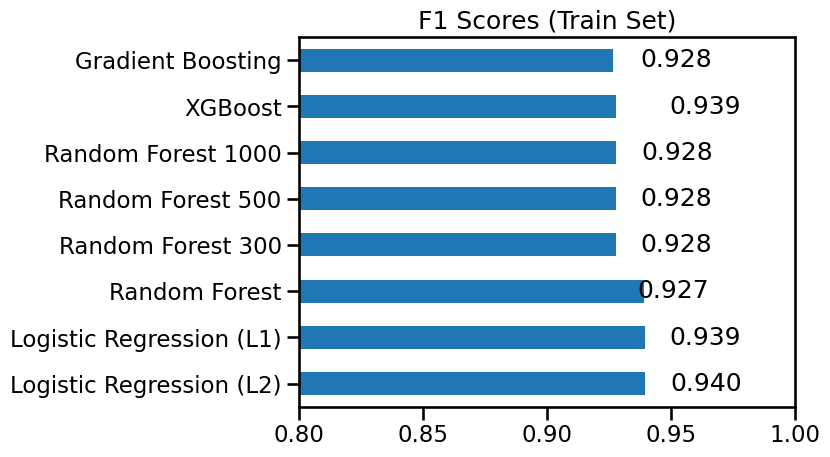

In [71]:
sns.set_context('talk')

# Plot the bar chart
ax = metrics_df['F1-score'].sort_values(ascending=False).plot(kind='barh')

plt.title('F1 Scores (Train Set)')

# Set y-axis limits
plt.xlim(0.8, 1.0)

# Add value annotations for each bar
for i, v in enumerate(metrics_df['F1-score']):
    ax.text(v + 0.01, i, f'{v:.3f}', ha='left', va='center')

# Set x-axis labels
ax.set_yticklabels(metrics_df.Model)

plt.show()

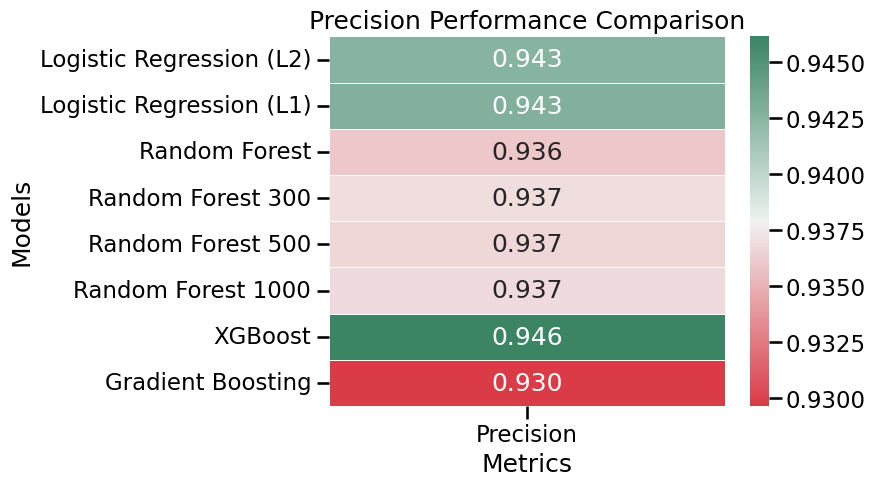

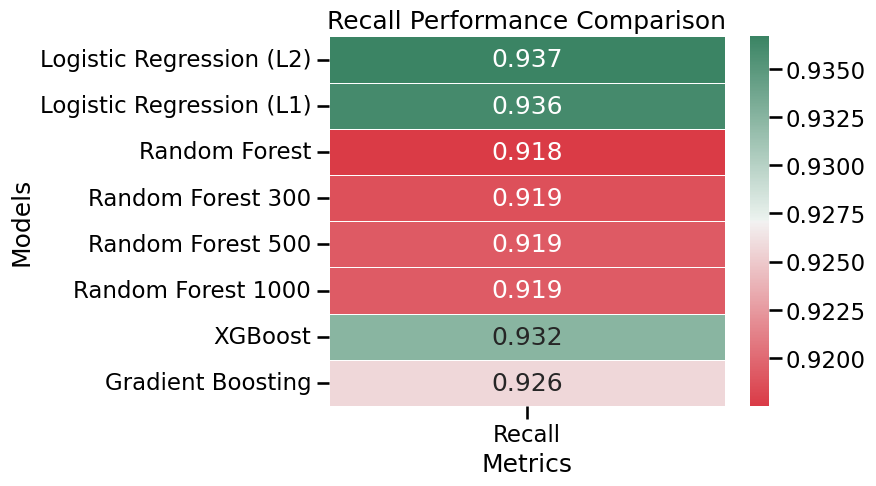

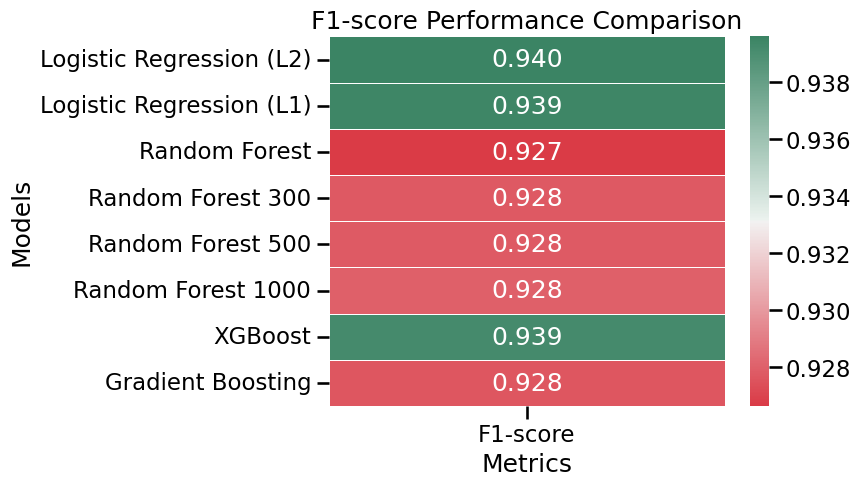

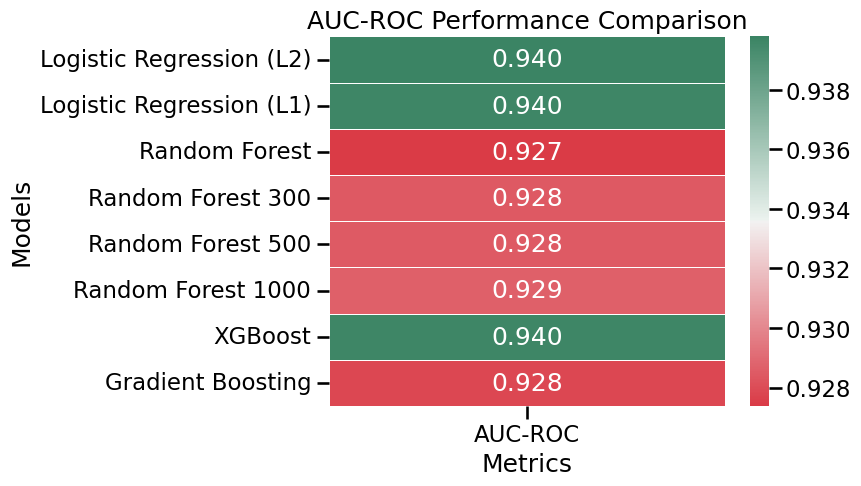

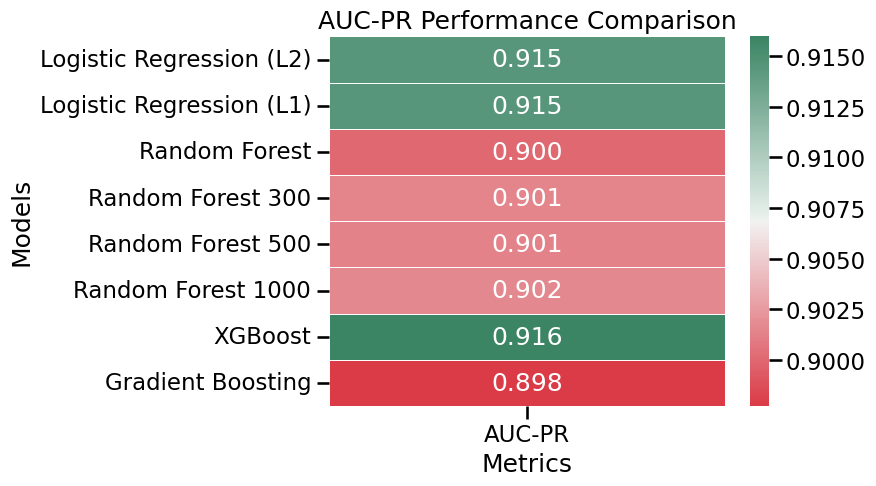

In [84]:
# Define the colormap for each metric
colormaps = {}

# Calculate the minimum and maximum values for each metric
for metric in metrics_df.columns:
    min_value = metrics_df[metric].min()
    max_value = metrics_df[metric].max()
    colormaps[metric] = sns.diverging_palette(10, 150, as_cmap=True, center='light', n=256)

# Plot the heatmap for each metric
for metric in metrics_df.columns:
    sns.heatmap(metrics_df[[metric]], cmap=colormaps[metric], annot=True, fmt=".3f", linewidths=.5)

    plt.title(f'{metric} Performance Comparison')
    plt.xlabel('Metrics')
    plt.ylabel('Models')
    plt.show()

In [86]:
# Set the 'Model' column as the index
#metrics_df.set_index('Model', inplace=True)

# Define a function to apply background gradient to highlight highest value in green and lowest value in red
def highlight_extreme(s):
    max_val = s.max()
    min_val = s.min()
    return ['background-color: green' if v == max_val else 'background-color: red' if v == min_val else '' for v in s]

# Apply the function to the DataFrame
print('Train Set')
styled_df = metrics_df.style.apply(highlight_extreme)

# Display the styled DataFrame
styled_df

Train Set


,Precision,Recall,F1-score,AUC-ROC,AUC-PR
Model,,,,,
Logistic Regression (L2),0.942544,0.936685,0.939598,0.939788,0.914522
Logistic Regression (L1),0.942812,0.936121,0.939447,0.939663,0.914521
Random Forest,0.936015,0.917502,0.926648,0.927376,0.900033
Random Forest 300,0.937004,0.918693,0.927737,0.928442,0.901462
Random Forest 500,0.936609,0.919195,0.927799,0.928473,0.901316
Random Forest 1000,0.936915,0.919257,0.927983,0.928661,0.901624
XGBoost,0.946127,0.932422,0.939217,0.939663,0.915980
Gradient Boosting,0.929641,0.925714,0.927656,0.927815,0.897715


In [122]:
# Set the 'Model' column as the index
metrics_df_test.set_index('Model', inplace=True)

# Apply the function to the DataFrame
print('Test Set')
styled_df_test = metrics_df_test.style.apply(highlight_extreme)

# Display the styled DataFrame
styled_df_test

Test Set


,Precision,Recall,F1-score,AUC-ROC,AUC-PR
Model,,,,,
Logistic Regression (L2),0.501005,0.937759,0.653091,0.940445,0.473394
Logistic Regression (L1),0.504245,0.938135,0.655930,0.940988,0.476600
Random Forest,0.481320,0.915758,0.630992,0.927836,0.445608
Random Forest 300,0.480476,0.918578,0.630933,0.929051,0.446028
Random Forest 500,0.478944,0.917450,0.629345,0.928338,0.444145
Random Forest 1000,0.478670,0.917826,0.629198,0.928481,0.444052
XGBoost,0.522543,0.934938,0.670397,0.941462,0.492280
Gradient Boosting,0.454772,0.928357,0.610486,0.930294,0.426302


C:\Users\mfncn\AppData\Local\Temp\ipykernel_9712\3998940107.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sorted_df[metric], y=sorted_df.index, palette="RdYlGn")
C:\Users\mfncn\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\mfncn\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_

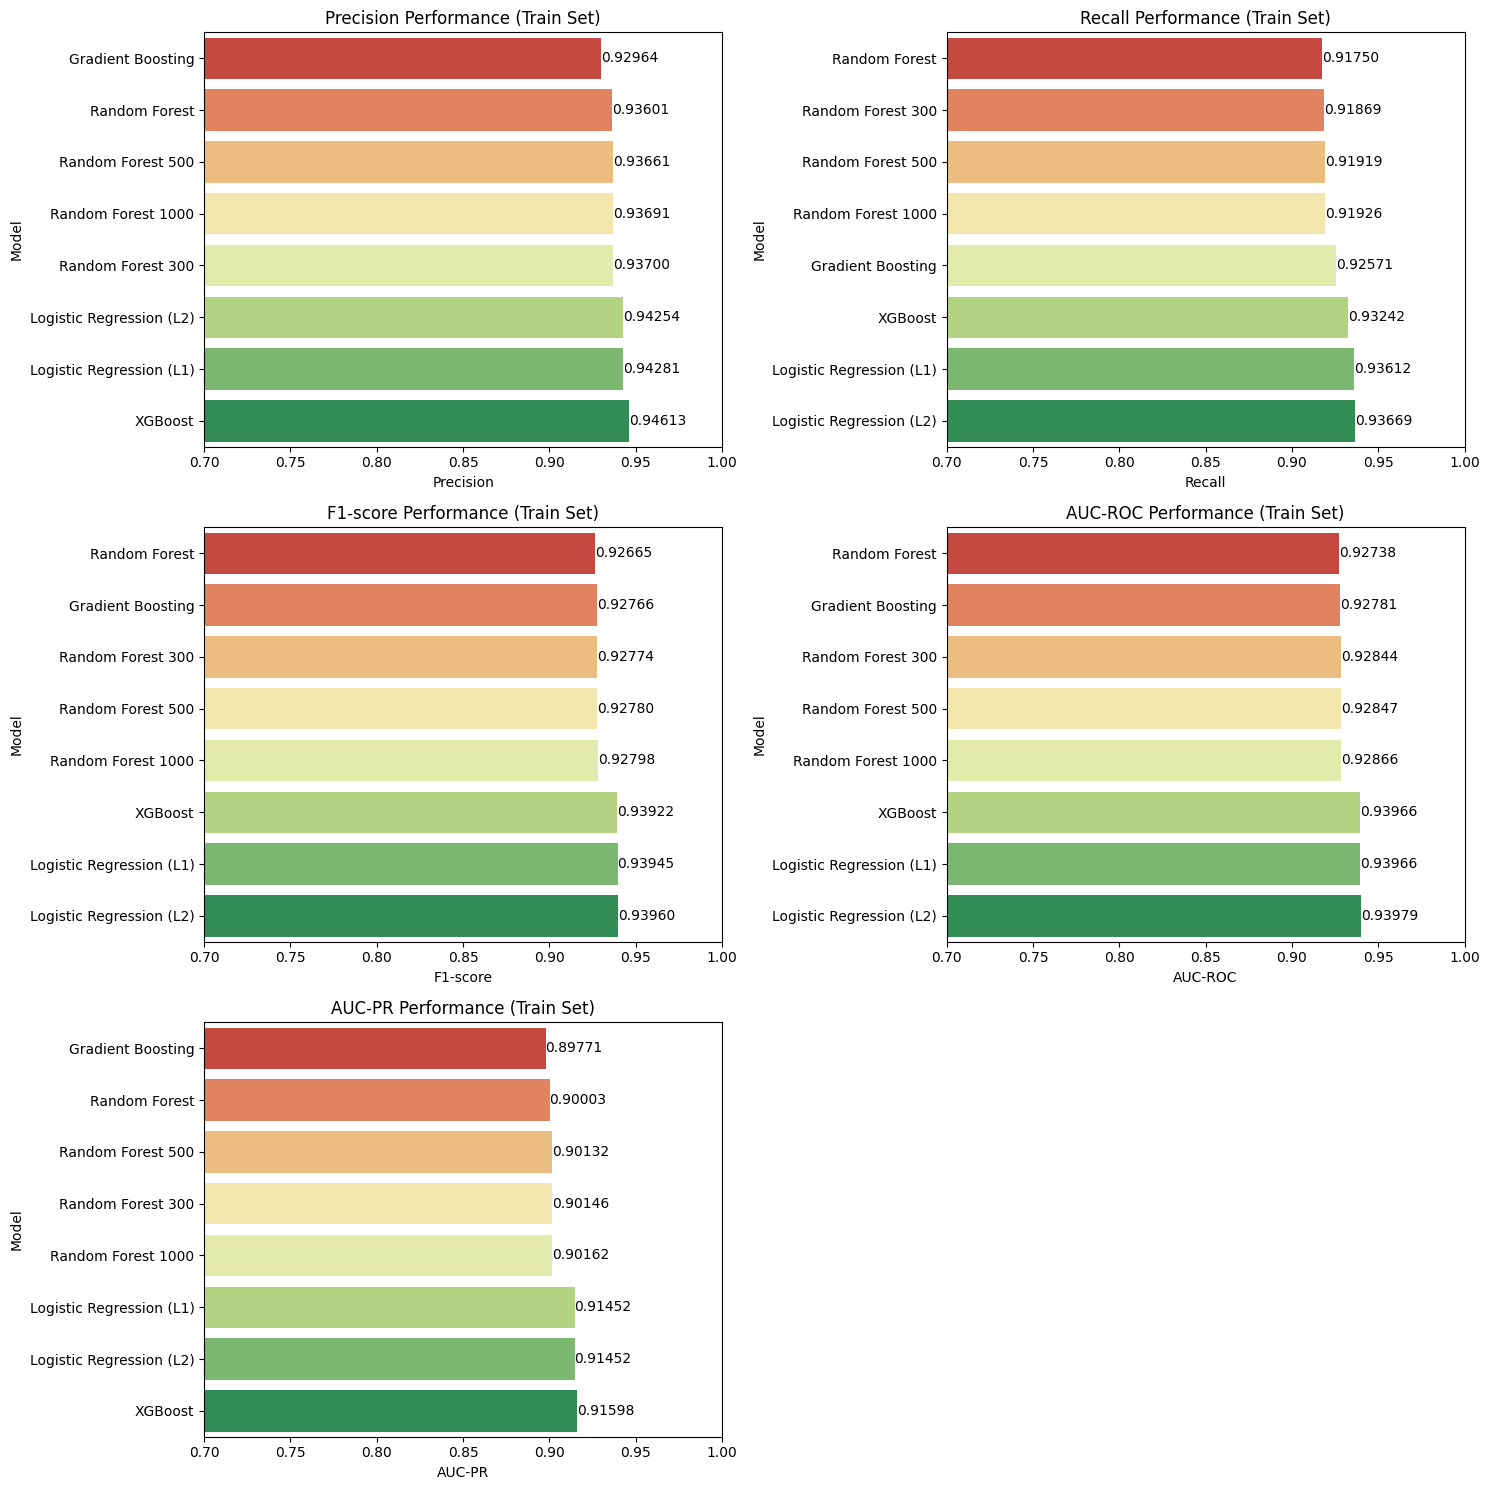

In [110]:
# Reset seaborn defaults
#sns.reset_defaults()

# Define the number of metrics and models
num_metrics = len(metrics_df.columns)
num_models = len(metrics_df)

# Calculate the number of rows needed for the grid
num_rows = num_metrics // 2 + (1 if num_metrics % 2 != 0 else 0)

# Set the figure size
plt.figure(figsize=(15, 5*num_rows))

# Loop through each metric
for i, metric in enumerate(metrics_df.columns):
    # Sort the DataFrame by the current metric
    sorted_df = metrics_df.sort_values(by=metric, ascending=True)
    
    # Create a subplot for the current metric
    plt.subplot(num_rows, 2, i+1)
    
    # Create a bar plot for the current metric
    ax = sns.barplot(x=sorted_df[metric], y=sorted_df.index, palette="RdYlGn")
    
    # Set the x-axis limits
    plt.xlim(0.7, 1.0)
    
    # Set the title and labels
    plt.title(f'{metric} Performance (Train Set)')
    plt.xlabel(metric)
    plt.ylabel('Model')
    
    # Add annotations for each bar
    for bar, val in zip(ax.patches, sorted_df[metric]):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'{val:.5f}', 
                ha='left', va='center')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

In [119]:
def plot_model_metrics(metrics_df, x_low=0):
    # Reset seaborn defaults
    #sns.reset_defaults()

    # Define the number of metrics and models
    num_metrics = len(metrics_df.columns)
    num_models = len(metrics_df)

    # Calculate the number of rows needed for the grid
    num_rows = num_metrics // 2 + (1 if num_metrics % 2 != 0 else 0)

    # Set the figure size
    plt.figure(figsize=(15, 5*num_rows))

    # Loop through each metric
    for i, metric in enumerate(metrics_df.columns):
        # Sort the DataFrame by the current metric
        sorted_df = metrics_df.sort_values(by=metric, ascending=True)

        # Create a subplot for the current metric
        plt.subplot(num_rows, 2, i+1)

        # Create a bar plot for the current metric
        ax = sns.barplot(x=sorted_df[metric], y=sorted_df.index, palette="RdYlGn")

        # Set the x-axis limits
        plt.xlim(x_low, 1.0)

        # Set the title and labels
        plt.title(f'{metric} Performance (Test Set)')
        plt.xlabel(metric)
        plt.ylabel('Model')

        # Add annotations for each bar
        for bar, val in zip(ax.patches, sorted_df[metric]):
            ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'{val:.5f}', 
                    ha='left', va='center')

    # Adjust layout
    plt.tight_layout()

    # Show the plot
    plt.show()

C:\Users\mfncn\AppData\Local\Temp\ipykernel_9712\3612549530.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sorted_df[metric], y=sorted_df.index, palette="RdYlGn")
C:\Users\mfncn\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\mfncn\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_

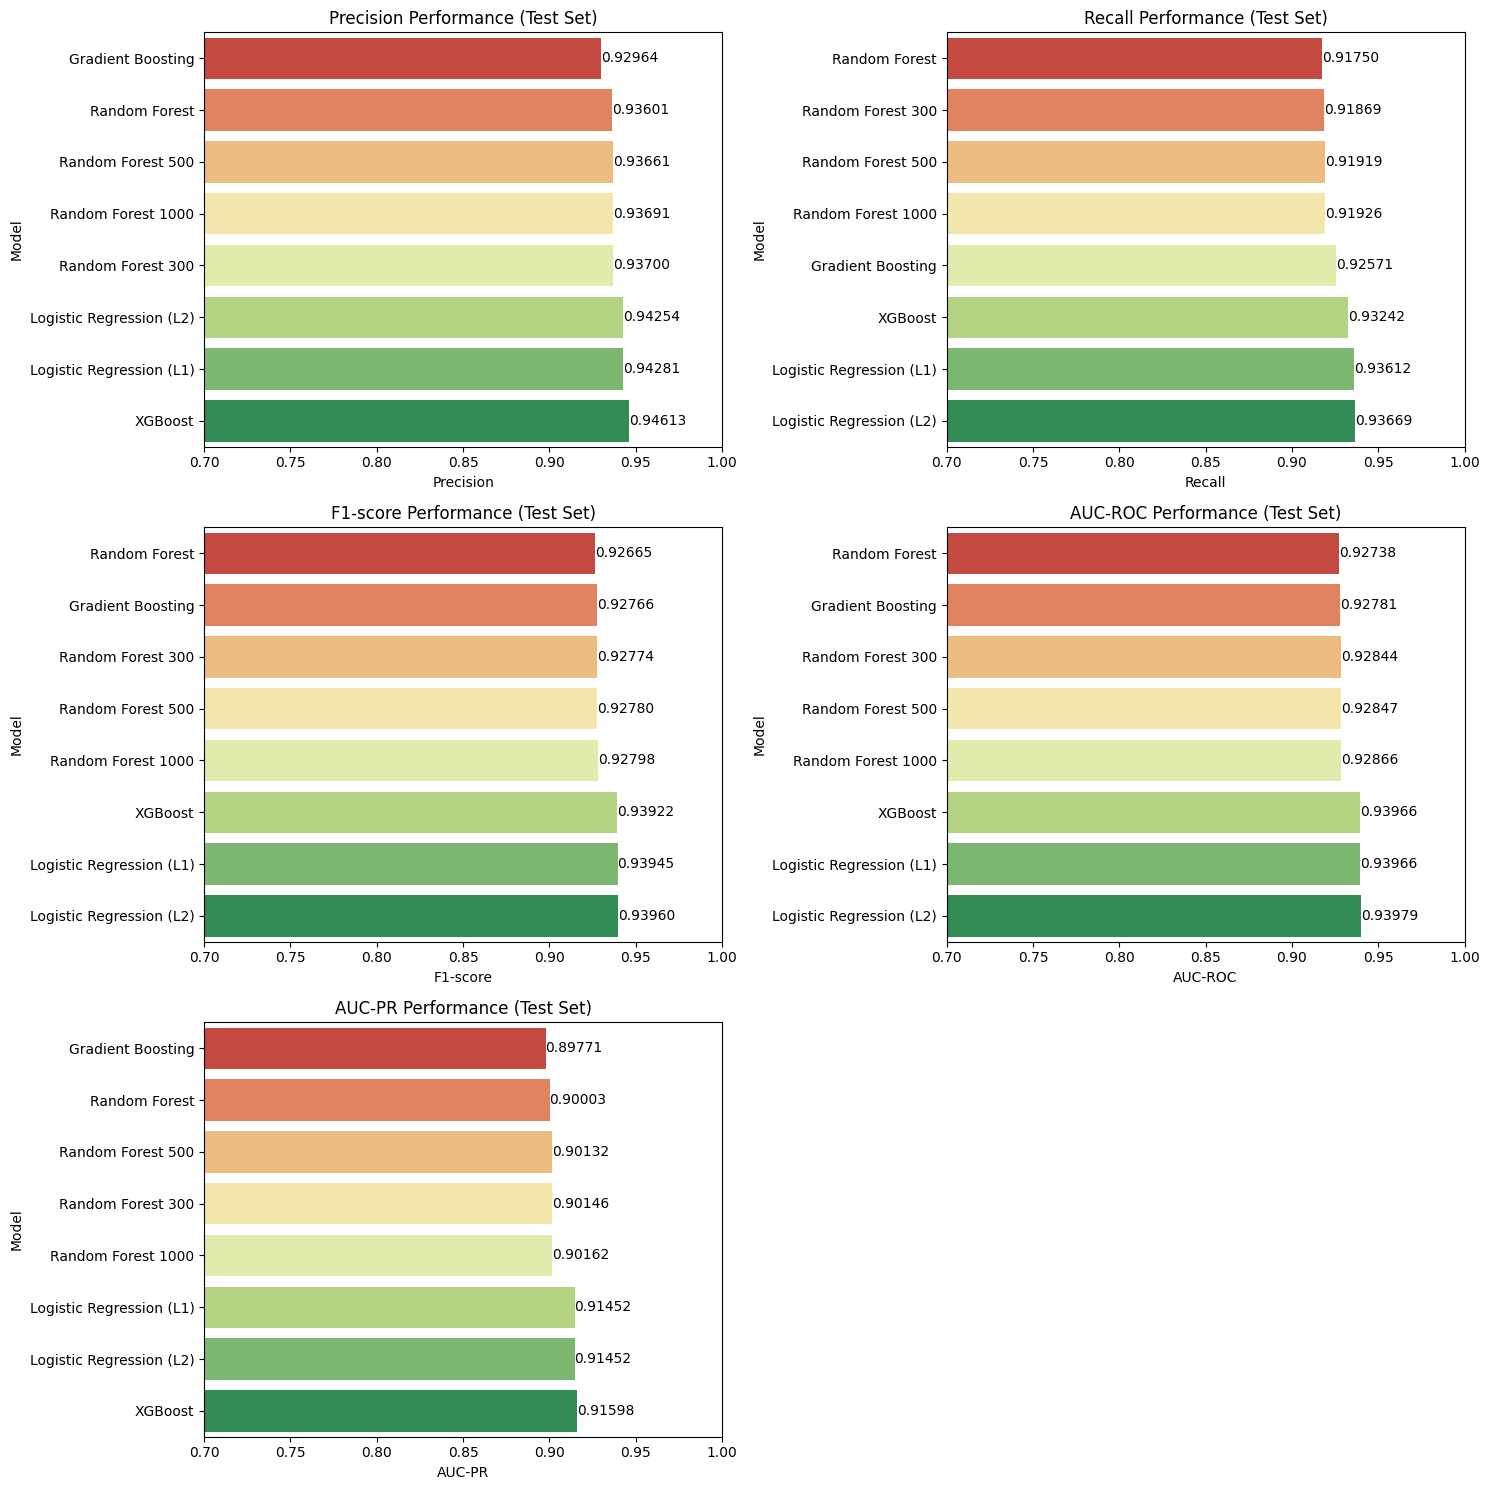

In [120]:
plot_model_metrics(metrics_df, x_low=0.7)

C:\Users\mfncn\AppData\Local\Temp\ipykernel_9712\3612549530.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sorted_df[metric], y=sorted_df.index, palette="RdYlGn")
C:\Users\mfncn\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\mfncn\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_

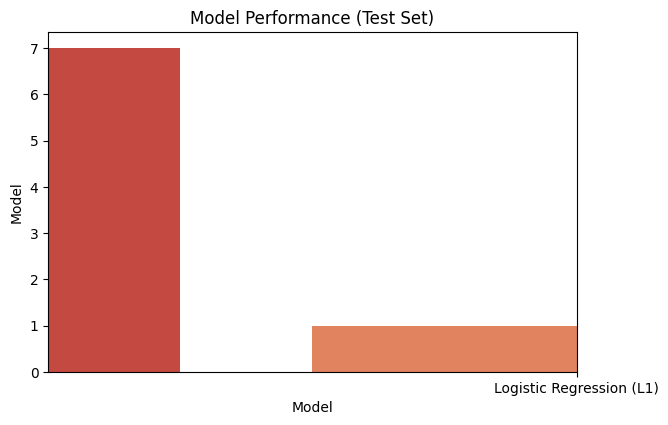

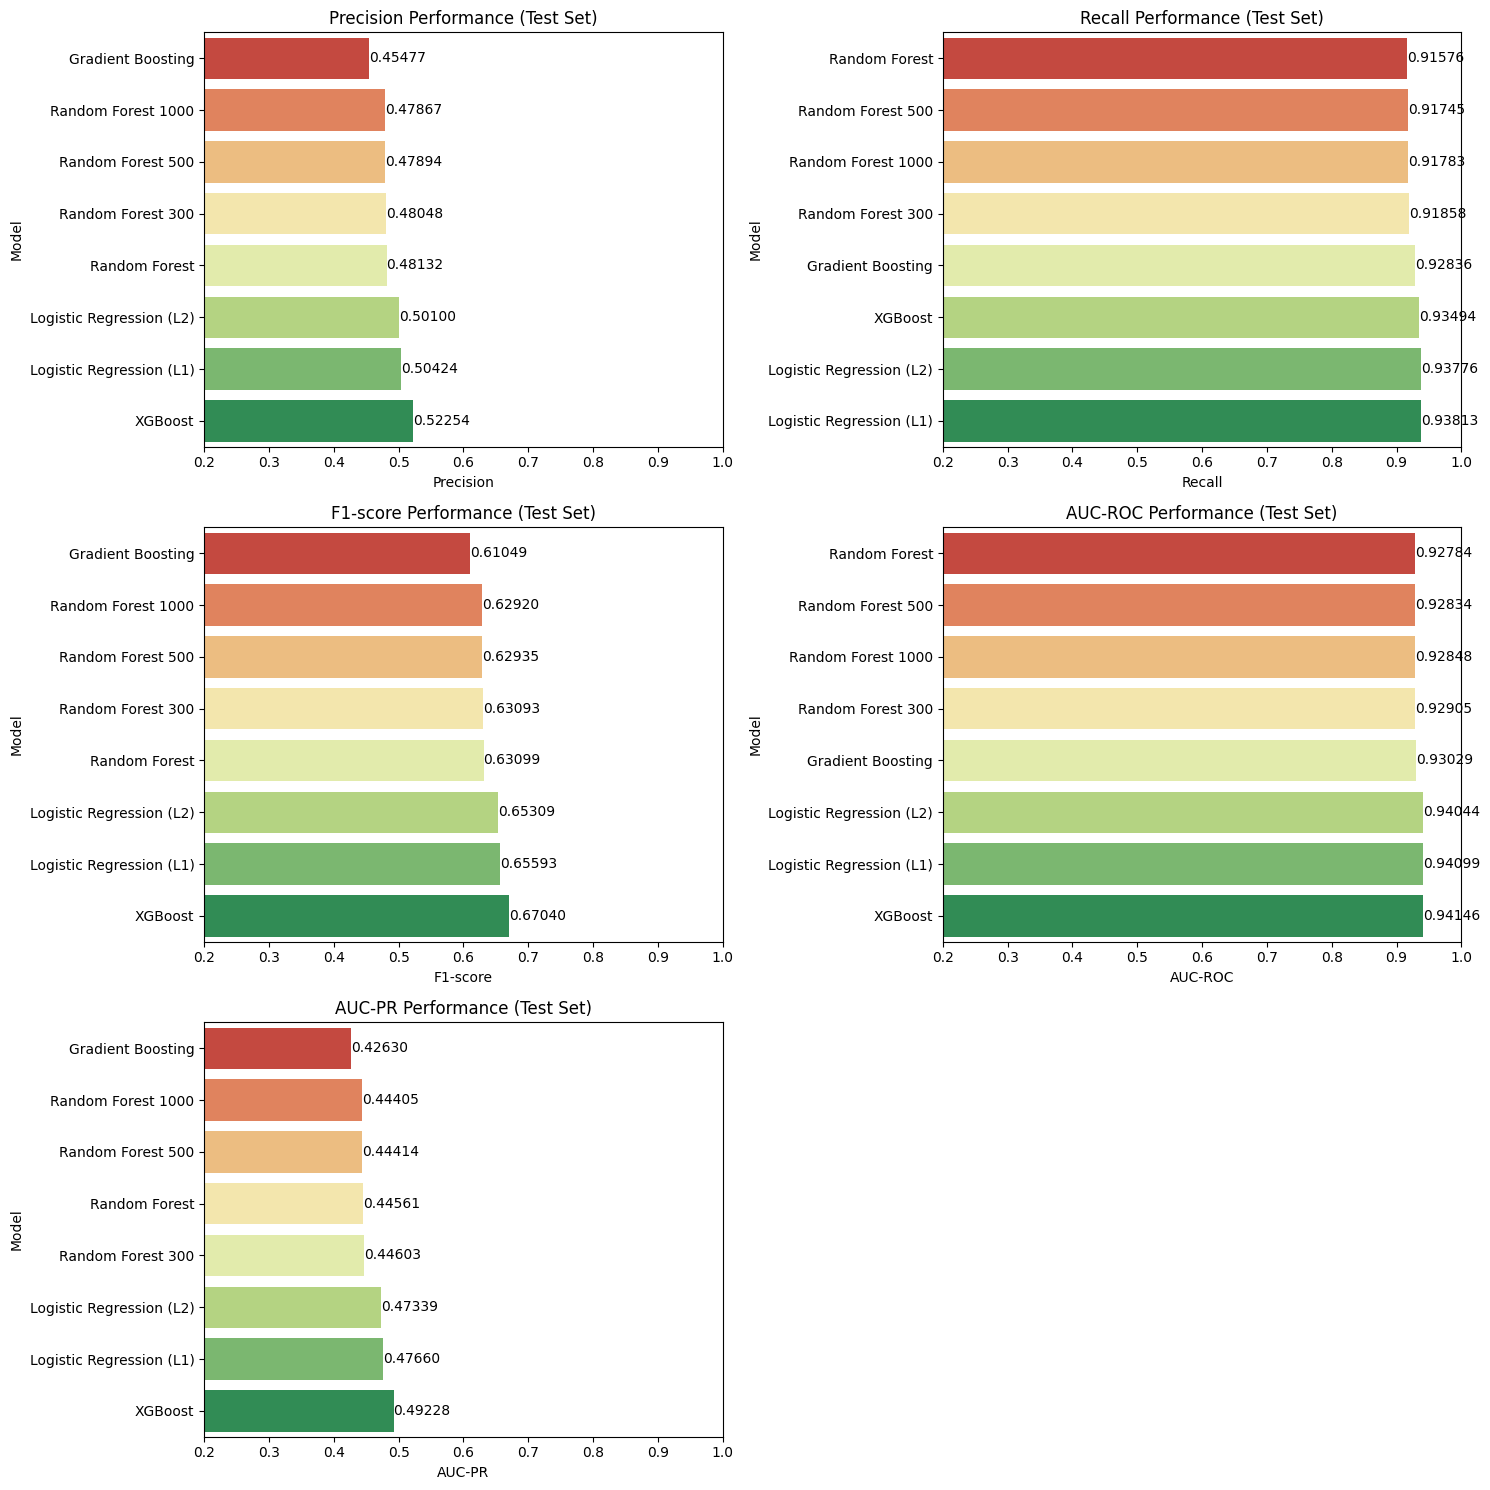

In [123]:
plot_model_metrics(metrics_df_test, x_low=0.2)

### **Best Model**

In [ ]:
# Get predicted probabilities for the positive class (mortality) as risk scores
# This will give you an array of predicted probabilities, where each element represents the probability of the positive class for the corresponding instance
#predicted_probabilities_train = best_model_lr.predict_proba(X_train_scaled)[:, 1]

In [124]:
# new
from sklearn.model_selection import cross_val_predict

# Perform cv to obtain predicted probabilities for each fold
predicted_probabilities_train = cross_val_predict(best_model_xgb, X_train_scaled, y_train, cv=cv, method='predict_proba')

# Extract the probabilities for the positive class (mortality)
predicted_probabilities_train_positive_class = predicted_probabilities_train[:, 1]

# Display the predicted probabilities
print(predicted_probabilities_train_positive_class)

[0.03021001 0.68534446 0.05549011 ... 0.86549914 0.99904066 0.9990225 ]


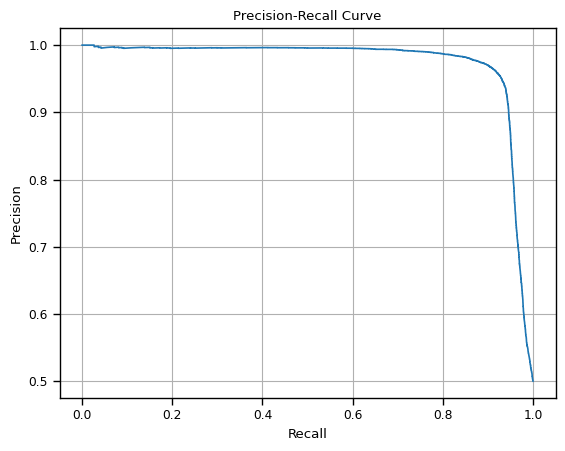

In [125]:
# new
# Plot precision-recall curves to visualize how precision and recall change as the threshold for classifying positive instances changes

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train, predicted_probabilities_train_positive_class)

# Plot precision-recall curve
sns.set_context('paper')
plt.plot(recalls, precisions)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

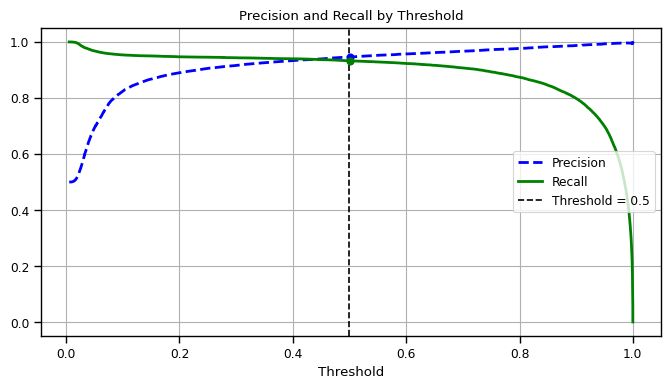

In [126]:
# new
plt.figure(figsize=(8, 4))  # extra code – it's not needed, just formatting
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
#plt.vlines(thresholds, 0, 0.5, "k", "dotted", label="threshold")

# Plot vertical line for threshold
plt.axvline(x=0.5, color="k", linestyle="--", label="Threshold = 0.5")

# Plot markers for threshold point
idx = (thresholds >= 0.5).argmax()  # first index ≥ threshold
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.grid()
plt.title('Precision and Recall by Threshold')
plt.xlabel("Threshold")
plt.legend(loc="center right")
plt.show()

### **Making Predictions on Test Set**

Logistic Regression

Logistic Regression Metrics:
Precision: 0.50231808103205
Recall: 0.9371944339977435
F1-score: 0.6540682414698162


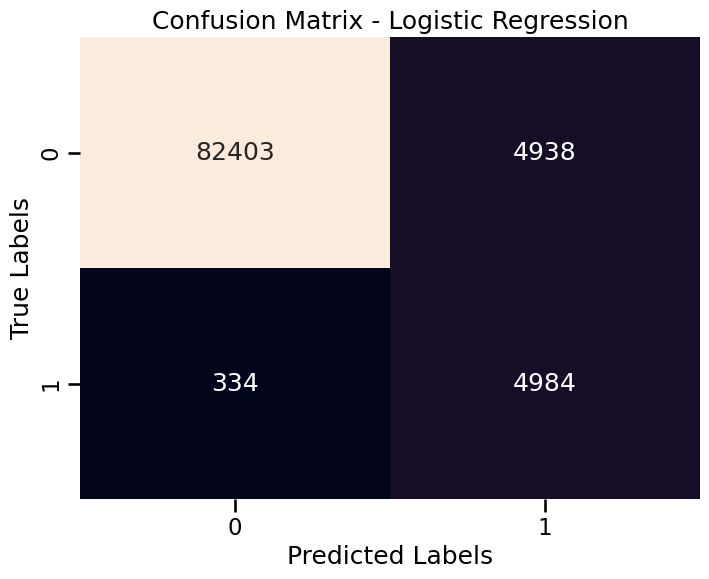

In [127]:
# Make predictions using Logistic Regression model
y_pred_lr_test = best_model_lr.predict(X_test_scaled)

# Calculate precision, recall, and F1-score
precision_lr_test = precision_score(y_test, y_pred_lr_test)
recall_lr_test = recall_score(y_test, y_pred_lr_test)
f1_lr_test = f1_score(y_test, y_pred_lr_test)

# Print precision, recall, and F1-score
print("Logistic Regression Metrics:")
print("Precision:", precision_lr_test)
print("Recall:", recall_lr_test)
print("F1-score:", f1_lr_test)

# Plot confusion matrix
sns.set_context('talk')
plt.figure(figsize=(8, 6))
conf_matrix_lr_test = confusion_matrix(y_test, y_pred_lr_test)
sns.heatmap(conf_matrix_lr_test, annot=True, fmt="d", cbar=False)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

XGBoost Classifier

XGBoost Metrics:
Precision: 0.5240012715905479
Recall: 0.9298608499435879
F1-score: 0.6702812605896307


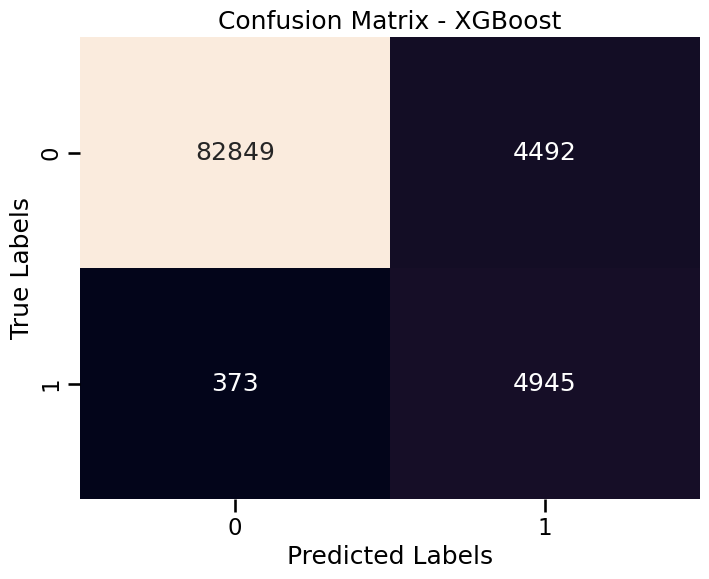

In [130]:
# Make predictions using XGBoost model
y_pred_xgb_test = best_model_xgb.predict(X_test_scaled)

# Calculate precision, recall, and F1-score
precision_xgb_test = precision_score(y_test, y_pred_xgb_test)
recall_xgb_test = recall_score(y_test, y_pred_xgb_test)
f1_xgb_test = f1_score(y_test, y_pred_xgb_test)

# Print precision, recall, and F1-score
print("XGBoost Metrics:")
print("Precision:", precision_xgb_test)
print("Recall:", recall_xgb_test)
print("F1-score:", f1_xgb_test)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
conf_matrix_xgb_test = confusion_matrix(y_test, y_pred_xgb_test)
sns.heatmap(conf_matrix_xgb_test, annot=True, fmt="d", cbar=False)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - XGBoost")
plt.show()

In [131]:
# new
# Generate predicted probabilities for the positive class (class 1) on the test set
predicted_probabilities_test = best_model_xgb.predict_proba(X_test_scaled)

# Extract probabilities for the positive class (class 1)
predicted_probabilities_test_positive_class = predicted_probabilities_test[:, 1]

In [132]:
import plotly.graph_objects as go
from sklearn.metrics import precision_recall_curve

In [133]:
# Calculate precision and recall
precisions_test, recalls_test, thresholds_test = precision_recall_curve(y_test, predicted_probabilities_test_positive_class)

# Create an interactive precision-recall curve
fig = go.Figure()

# Add precision-recall curve
#fig.add_trace(go.Scatter(x=recalls_test, y=precisions_test, mode='lines', name='Precision-Recall Curve'))

fig.add_trace(go.Scatter(x=recalls_test, y=precisions_test, mode='lines',
                         hovertemplate='Recall: %{x:.2f}<br>Precision: %{y:.2f}<br>Threshold: %{text:.2f}',
                         text=thresholds_test, name='Precision-Recall Curve'))

# Update layout
fig.update_layout(title='Precision-Recall Curve - Test Set',
                  xaxis_title='Recall',
                  yaxis_title='Precision',
                  hovermode='closest',
                  width=800,
                  height=700,
                  xaxis=dict(
        title_font=dict(size=20),  # Set the font size for x-axis label
        tickfont=dict(size=20)  # Set the font size for x-axis tick label
    ),
    yaxis=dict(
        title_font=dict(size=20),  # Set the font size for y-axis label
        tickfont=dict(size=20)  # Set the font size for y-axis tick labels
    ))

# Show plot
fig.show()

Feature Importance

We can analyze the importance of features in a logistic regression model by examining the coefficients associated with each feature. Since logistic regression is a linear model, the magnitude of the coefficients provides information about the importance of each feature in predicting the target variable.  

This plot will show you the relative importance of each feature in the logistic regression model. Features with larger absolute coefficient values are considered more important in predicting the target variable. 

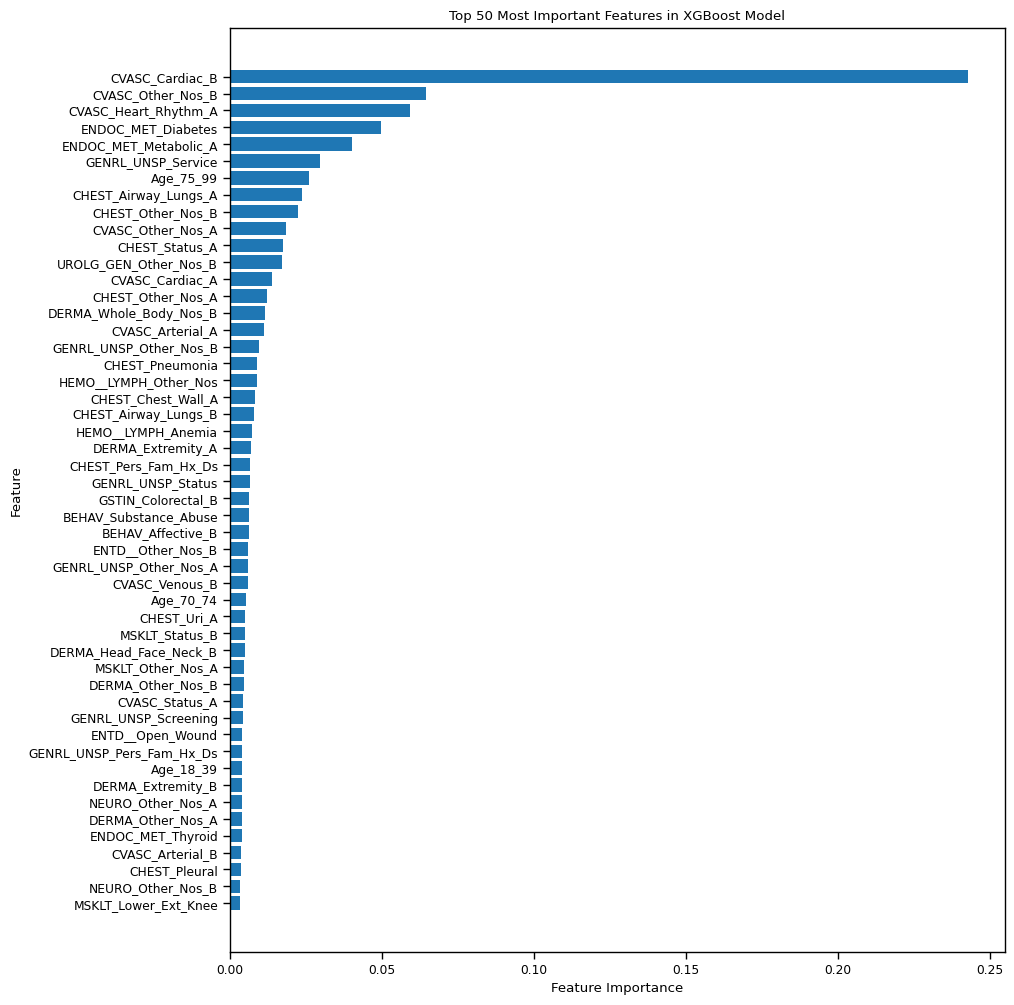

In [137]:
# new
# Get the feature importances
feature_importances = best_model_xgb.feature_importances_
# Get the feature names
feature_names = X_train.columns

# Sort feature importances and feature names
indices = np.argsort(feature_importances)
sorted_feature_importances = feature_importances[indices]
sorted_feature_names = feature_names[indices]

# Select top 50 most important features
top_50_importances = sorted_feature_importances[-50:]
top_50_feature_names = sorted_feature_names[-50:]

# Plot top 50 most important features
sns.set_context('paper')
plt.figure(figsize=(10, 12))
plt.barh(range(len(top_50_feature_names)), top_50_importances, align='center')
plt.yticks(range(len(top_50_feature_names)), top_50_feature_names)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 50 Most Important Features in XGBoost Model')
plt.show()